# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ - Open boundary conditions fixed point check

Created: 21-07-2026

Objectives:
* Continue from [previous notebook](z2_f_x_z2_t_obc_fixed_point_check.ipynb), now just focussing on fixed points.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed_obc"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed_obc"

# Import states

In [12]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]

In [13]:
triv_energies = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

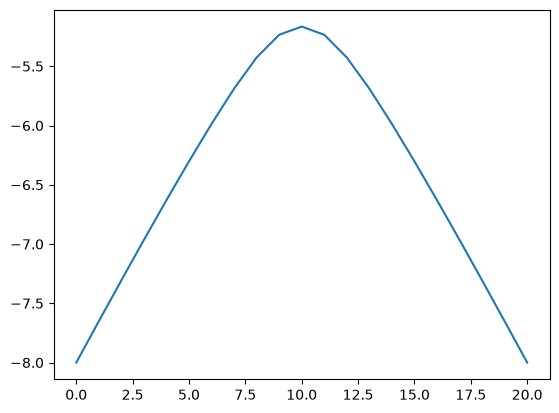

In [14]:
plt.plot(triv_energies)

Something weird happening at $t=1$...

In [17]:
"""
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]
"""

"\nnontriv_groundstates = [\n    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]\n    for i in range(0, 101, 5)\n]\n"

In [18]:
"""
nontriv_groundstates[0].shape
"""

'\nnontriv_groundstates[0].shape\n'

In [19]:
"""
nontriv_energies = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]
"""

"\nnontriv_energies = [\n    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['energy']\n    for i in range(0, 101, 5)\n]\n"

In [20]:
#plt.plot(nontriv_energies)

Hmm, the degenerate groundspae is not robust here...?

# Definitions

In [21]:
L = 10

In [22]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [23]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [24]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [25]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [26]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [27]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [28]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [29]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [30]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [31]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [32]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [33]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [34]:
def get_defect_ops_and_indices_from_rho_tilde(
    qt_rho, rho_tilde, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

# Check

In [35]:
psi = triv_groundstates[-1]

In [36]:
psi.shape

(1048576,)

In [37]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(7, 14)),
    'left_defect_sites': [7,],
    'right_defect_sites': [13,]
}

all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [56]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)
qt_psi.isel({'k19': 1}, inplace=True)

left_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

right_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
    absorb=None,
    bond_ind='vR'
)

psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

rho_trace_test = (psi_s & psi_s.conj()).contract()

rho_tilde = (
    psi_s
    & psi_s.reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
)

rho_tilde.contract(
    output_inds=rho_tilde.outer_inds(),
    inplace=True
)

edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

qt_rho = (
    qt_psi
    & qt_psi.conj().reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
)

defect_out = get_defect_ops_and_indices_from_rho_tilde(
    qt_rho,
    rho_tilde,
    domains_dict
)

In [57]:
rho_trace_test

np.complex128(0.9999999999999999+0j)

In [58]:
defect_out[0]

array([0.0369486])

In [59]:
defect_out[-1]

np.float64(0.07389719351542465)

In [60]:
defect_out[3], defect_out[4]

(np.complex128(-1.0000000000000087+0j), np.complex128(-1.0000000000000089+0j))

In [61]:
defect_out[5], defect_out[6]

(np.complex128(-1.0000000000000087+0j), np.complex128(-1.0000000000000089+0j))

In [62]:
np.round(defect_out[1].data, 3)

array([[ 0.   +0.j   , -0.159-0.987j],
       [ 0.159+0.987j, -0.   +0.j   ]])

In [63]:
np.round(defect_out[2].data, 3)

array([[ 0.   -0.j   , -0.978-0.208j],
       [ 0.978+0.208j,  0.   +0.j   ]])

In [64]:
edm

Tensor(shape=(2, 2, 2, 2), inds=('kl', 'bl', 'kr', 'br'), tags=oset([]))

In [65]:
np.round(edm.data, 3)

array([[[[ 0.   -0.j   ,  0.   +0.j   ],
         [ 0.   +0.j   ,  0.   -0.j   ]],

        [[-0.   +0.j   , -0.001-0.018j],
         [ 0.001+0.018j, -0.   -0.j   ]]],


       [[[-0.   +0.j   ,  0.001+0.018j],
         [-0.001-0.018j, -0.   -0.j   ]],

        [[ 0.   +0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  0.   -0.j   ]]]])

In [52]:
rho = (
    psi_s
    & psi_s.conj().reindex({'k7': 'b7', 'k13': 'b13'})
).contract()

In [53]:
rho

Tensor(shape=(2, 2, 2, 2), inds=('k7', 'k13', 'b7', 'b13'), tags=oset([]))

In [55]:
np.round(rho.data.reshape(4,4), 3)

array([[ 0.25+0.j,  0.  +0.j, -0.  -0.j, -0.  +0.j],
       [ 0.  -0.j,  0.25+0.j,  0.  -0.j, -0.  -0.j],
       [-0.  +0.j,  0.  +0.j,  0.25+0.j,  0.  +0.j],
       [-0.  +0.j, -0.  +0.j,  0.  -0.j,  0.25+0.j]])

Yep, as expected.

# Sweep

In [33]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(6, 14)),
    'left_defect_sites': [6, 7],
    'right_defect_sites': [12, 13]
}

all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [34]:
triv_results = list()

for psi in tqdm(triv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )
    qt_psi.isel({'k19': 1}, inplace=True)

    left_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites],
        absorb=None,
        bond_ind='vL'
    )

    right_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
        absorb=None,
        bond_ind='vR'
    )

    psi_s = (
        qt_psi
        & left_schmidt_decomp.tensors[0].conj()
        & right_schmidt_decomp.tensors[2].conj()
    ).contract()

    rho_trace_test = (psi_s & psi_s.conj()).contract()

    rho_tilde = (
        psi_s
        & psi_s.reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    rho_tilde.contract(
        output_inds=rho_tilde.outer_inds(),
        inplace=True
    )

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    qt_rho = (
        qt_psi
        & qt_psi.conj().reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    defect_out = get_defect_ops_and_indices_from_rho_tilde(
        qt_rho,
        rho_tilde,
        domains_dict
    )

    triv_results.append([rho_trace_test, *defect_out])

100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:04<00:00,  5.20it/s]


In [35]:
nontriv_results = list()

for psi in tqdm(nontriv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )
    qt_psi.isel({'k19': 1}, inplace=True)

    left_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites],
        absorb=None,
        bond_ind='vL'
    )

    right_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
        absorb=None,
        bond_ind='vR'
    )

    psi_s = (
        qt_psi
        & left_schmidt_decomp.tensors[0].conj()
        & right_schmidt_decomp.tensors[2].conj()
    ).contract()

    rho_trace_test = (psi_s & psi_s.conj()).contract()

    rho_tilde = (
        psi_s
        & psi_s.reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    rho_tilde.contract(
        output_inds=rho_tilde.outer_inds(),
        inplace=True
    )

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    qt_rho = (
        qt_psi
        & qt_psi.conj().reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    defect_out = get_defect_ops_and_indices_from_rho_tilde(
        qt_rho,
        rho_tilde,
        domains_dict
    )

    nontriv_results.append([rho_trace_test, *defect_out])

100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:02<00:00,  7.15it/s]


## Analyze results
### Trivial

In [36]:
[
    l[0] for l in triv_results
]

[np.complex128(1.0000000000000115+0j),
 np.complex128(1.0000000000000067+0j),
 np.complex128(1.0000000000000155+0j),
 np.complex128(1.0000000000000089+0j),
 np.complex128(1.0000000000000087+0j),
 np.complex128(0.9999999999999937+0j),
 np.complex128(1.0000000000000024+0j),
 np.complex128(0.9999999999999785+0j),
 np.complex128(1.0000000000000022+0j),
 np.complex128(1.0000000000000044+0j),
 np.complex128(1.000000000000029+0j),
 np.complex128(1.000000000000007+0j),
 np.complex128(1.0000000000000007+0j),
 np.complex128(1.0000000000000084+0j),
 np.complex128(1.0000000000000029+0j),
 np.complex128(0.9999999999999936+0j),
 np.complex128(1.0000000000000013+0j),
 np.complex128(0.9999999999999885+0j),
 np.complex128(1.000000000000016+0j),
 np.complex128(1.0000000000000107+0j),
 np.complex128(1.0000000000000235+0j)]

In [38]:
[
    l[1] for l in triv_results
]

[array([0.95012748]),
 array([9.96709468e-01, 1.36481588e-04, 4.54761347e-05, 2.90116312e-07,
        2.79870766e-07, 7.09340480e-08, 6.82723683e-08, 9.42431997e-09]),
 array([9.90404552e-01, 6.41918222e-04, 2.11959543e-04, 3.04694309e-06,
        2.91837980e-06, 7.41412722e-07, 7.08578268e-07, 2.06160497e-07,
        1.47140096e-09, 1.40712732e-09, 4.92924381e-10, 4.71564867e-10]),
 array([8.03410684e-01, 1.40687182e-03, 4.61757472e-04, 1.21561570e-05,
        1.00125794e-05, 2.94809202e-06, 2.40746701e-06, 1.19809542e-06,
        1.11532556e-08, 9.20425902e-09, 4.06482986e-09, 3.36244814e-09,
        2.61407634e-10]),
 array([9.78113990e-01, 3.71983239e-03, 1.25767121e-03, 4.89264777e-05,
        4.08702973e-05, 1.17417401e-05, 9.76284787e-06, 6.80267034e-06,
        7.62533648e-08, 6.37549443e-08, 3.01154648e-08, 2.49098344e-08,
        3.18877723e-10]),
 array([7.05230491e-01, 5.21950727e-03, 1.99025859e-03, 1.16363137e-04,
        7.47273452e-05, 2.76526935e-05, 1.90523506e-05, 1.

In [41]:
n1_invariants = np.array([
    [l[4], l[5]] for l in triv_results
])

In [42]:
np.round(n1_invariants, 3)

array([[ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 0.694-0.j,  0.694+0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-0.45 +0.j, -0.879-0.j]])

Something funny happening at the end, likely Hamiltonian specific.

In [45]:
cocycle_invariants = np.array([
    [l[6], l[7]] for l in triv_results
])

In [46]:
np.round(cocycle_invariants, 3)

array([[ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 0.694-0.j,  0.694+0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   -0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j]])

But the cocycle invariant is still wrong! Interesting.

In [49]:
overlaps = [l[-1] for l in triv_results]

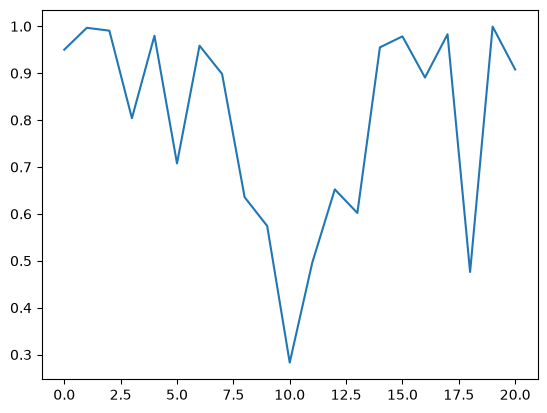

In [50]:
plt.plot(overlaps)

Much noisier overlaps than I was expecting...! Dependent on the choice of boundary/edge states?

### Non-trivial

In [51]:
[
    l[0] for l in nontriv_results
]

[np.complex128(1.0000000000000013+0j),
 np.complex128(1.0000000000000082+0j),
 np.complex128(1.000000000000007+0j),
 np.complex128(1.0000000000000293+0j),
 np.complex128(1.0000000000000107+0j),
 np.complex128(1.00000000000001+0j),
 np.complex128(1.0000000000000293+0j),
 np.complex128(1.0000000000000175+0j),
 np.complex128(1.0000000000000044+0j),
 np.complex128(0.9999999999999787+0j),
 np.complex128(0.9999999999999922+0j),
 np.complex128(1.0000000000000262+0j),
 np.complex128(1.000000000000018+0j),
 np.complex128(1.000000000000016+0j),
 np.complex128(1.000000000000011+0j),
 np.complex128(0.9999999999999964+0j),
 np.complex128(1.000000000000018+0j),
 np.complex128(0.999999999999996+0j),
 np.complex128(1.0000000000000573+0j),
 np.complex128(0.9999999999999811+0j),
 np.complex128(0.9999999999999855+0j)]

In [52]:
[
    l[1] for l in nontriv_results
]

[array([0.2412271 , 0.00123816]),
 array([2.49607229e-01, 6.57089401e-03, 8.70360551e-05, 6.85439669e-06]),
 array([2.45222706e-01, 1.36447889e-02, 3.93110966e-04, 6.46429380e-05]),
 array([0.2476544 , 0.02194599, 0.00094305, 0.00024946]),
 array([0.23114167, 0.02916476, 0.00181041, 0.00066306]),
 array([0.20119732, 0.03410722, 0.00535868, 0.0019318 ]),
 array([0.12486726, 0.02772211, 0.01690959, 0.00540637]),
 array([0.2017917 , 0.05707664, 0.01536062, 0.0104625 ]),
 array([0.1850291 , 0.0712059 , 0.01727741, 0.01476382]),
 array([0.14303814, 0.08064818, 0.03080163, 0.03065333]),
 array([0.10230297, 0.10230297, 0.03570479, 0.03570479]),
 array([0.13720594, 0.06989187, 0.04163665, 0.0373833 ]),
 array([0.17601856, 0.066038  , 0.02175152, 0.01926026]),
 array([0.20110744, 0.05785368, 0.01169032, 0.00823458]),
 array([0.18097795, 0.04018454, 0.01001195, 0.00421433]),
 array([0.22523821, 0.03819979, 0.00349756, 0.00169605]),
 array([0.16734775, 0.0229969 , 0.02112942, 0.00311767]),
 array

In [53]:
n1_invariants = np.array([
    [l[4], l[5]] for l in nontriv_results
])

In [54]:
np.round(n1_invariants, 3)

array([[-0.567+0.j,  0.378+0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   +0.j],
       [-0.234-0.j,  0.512+0.j]])

Something funny happening at the fixed points...?

In [55]:
cocycle_invariants = np.array([
    [l[6], l[7]] for l in nontriv_results
])

In [56]:
np.round(cocycle_invariants, 3)

array([[-1.   +0.j   , -1.   +0.j   ],
       [-1.   +0.j   , -1.   +0.j   ],
       [-1.   -0.j   , -1.   +0.j   ],
       [-1.   +0.j   , -1.   +0.j   ],
       [-1.   +0.j   , -1.   -0.j   ],
       [-1.   +0.j   , -1.   -0.j   ],
       [-1.   +0.j   , -1.   +0.j   ],
       [-1.   -0.j   , -1.   +0.j   ],
       [-1.   +0.j   , -1.   -0.j   ],
       [-1.   +0.j   , -1.   -0.j   ],
       [ 0.224+0.j   ,  0.224+0.073j],
       [ 1.   -0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   -0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   -0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ]])

But the cocycle invariant is the same as we had before! Interesting. So our invariant is definitely wrong.

In [57]:
overlaps = [l[-1] for l in triv_results]

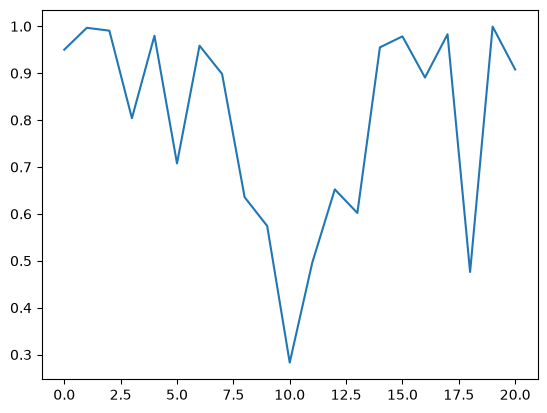

In [58]:
plt.plot(overlaps)

Still noisy...

### Defect operators

In [63]:
X =triv_results[0][2].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.162+0.j   , -0.903-0.389j,  0.   +0.j   ,  0.041+0.075j],
       [-0.874-0.162j, -0.084-0.07j ,  0.   -0.j   ,  0.255+0.365j],
       [-0.   -0.j   , -0.   -0.j   , -1.   -0.007j,  0.   -0.j   ],
       [-0.409-0.131j, -0.125-0.077j,  0.   -0.j   , -0.423-0.785j]])

In [64]:
X =triv_results[0][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.364+0.j   ,  0.404+0.036j,  0.   -0.j   ,  0.534+0.646j],
       [-0.151+0.912j,  0.117-0.233j,  0.   -0.j   ,  0.227-0.163j],
       [-0.   -0.j   ,  0.   +0.j   ,  0.452-0.892j, -0.   -0.j   ],
       [ 0.115+0.009j,  0.672+0.562j, -0.   -0.j   , -0.064-0.464j]])

In [68]:
X =triv_results[-1][2].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[ 0.   +0.j,  0.261+0.j, -0.525+0.j, -0.81 -0.j],
       [-0.261+0.j,  0.   +0.j,  0.81 -0.j, -0.525+0.j],
       [ 0.525+0.j, -0.81 +0.j, -0.   -0.j, -0.261+0.j],
       [ 0.81 +0.j,  0.525-0.j,  0.261-0.j, -0.   +0.j]])

In [69]:
X =triv_results[-1][3].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[-0.   -0.j,  0.893+0.j,  0.246-0.j,  0.377+0.j],
       [-0.893+0.j,  0.   -0.j,  0.377+0.j, -0.246-0.j],
       [-0.246+0.j, -0.377+0.j,  0.   -0.j,  0.893+0.j],
       [-0.377-0.j,  0.246+0.j, -0.893-0.j,  0.   +0.j]])

In [71]:
X =nontriv_results[0][2].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[-0.   +0.j,  0.045-0.j,  0.465-0.j, -0.884+0.j],
       [-0.045+0.j, -0.   -0.j,  0.884-0.j,  0.465-0.j],
       [-0.465+0.j, -0.884+0.j,  0.   -0.j, -0.045+0.j],
       [ 0.884-0.j, -0.465+0.j,  0.045-0.j,  0.   -0.j]])

In [75]:
X =nontriv_results[0][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.   +0.j   , -0.201+0.28j ,  0.484-0.674j,  0.256-0.356j],
       [ 0.201-0.28j , -0.   -0.j   ,  0.256-0.356j, -0.484+0.674j],
       [-0.484+0.674j, -0.256+0.356j, -0.   +0.j   , -0.201+0.28j ],
       [-0.256+0.356j,  0.484-0.674j,  0.201-0.28j , -0.   +0.j   ]])

In [77]:
X =nontriv_results[-1][2].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.619-0.j   , -0.   -0.779j, -0.   +0.j   ,  0.   +0.101j],
       [ 0.   -0.779j,  0.619-0.j   , -0.   +0.101j,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   +0.101j,  0.619-0.j   ,  0.   +0.779j],
       [ 0.   +0.101j, -0.   +0.j   ,  0.   +0.779j,  0.619-0.j   ]])

In [79]:
X =nontriv_results[-1][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.869+0.j   ,  0.   +0.494j, -0.   +0.j   , -0.   +0.025j],
       [-0.   +0.494j,  0.869+0.j   ,  0.   -0.025j,  0.   -0.j   ],
       [-0.   +0.j   ,  0.   -0.025j,  0.869-0.j   ,  0.   +0.494j],
       [ 0.   +0.025j, -0.   -0.j   , -0.   +0.494j,  0.869-0.j   ]])

# Conclusions
1. Are there problems in our groundstate energies, especially in for the nontrivial cocycles? Problem in Hamiltonian definition?
2. The calculated $n_1$ values are cleaner here, indicating there is something wrong with the tensor network factorization.
3. The calculated values of $\nu_2$ look good, but seem multiplied by $(-1)^{n_1}$. Why?